In [1]:
# Simple test cell
print("Hello! Kernel is working!")
import sys
print(f"Python version: {sys.version}")

Hello! Kernel is working!
Python version: 3.14.4 (tags/v3.14.4:23116f9, Apr  7 2026, 14:10:54) [MSC v.1944 64 bit (AMD64)]


In [2]:
# Cell 1 - Import and load data
from ucimlrepo import fetch_ucirepo
import pandas as pd
import numpy as np

print("✅ Libraries imported!")
print(f"Python environment: {__import__('sys').prefix}")

# Load the dataset
ctg = fetch_ucirepo(id=193)
print("✅ Dataset loaded!")

# Check what we have
print(f"\nFeatures shape: {ctg.data.features.shape}")
print(f"Target shape: {ctg.data.targets.shape}")

✅ Libraries imported!
Python environment: c:\Users\Naeem\fetal-health-classification-ml-app\fetal_env
✅ Dataset loaded!

Features shape: (2126, 21)
Target shape: (2126, 2)


In [3]:
# See column names
print("Feature columns:")
print(ctg.data.features.columns.tolist())
print(f"\nNumber of features: {len(ctg.data.features.columns)}")

# Check the target columns
print("\nTarget columns:")
print(ctg.data.targets.columns.tolist())
print(ctg.data.targets.head())

Feature columns:
['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

Number of features: 21

Target columns:
['CLASS', 'NSP']
   CLASS  NSP
0      9    2
1      6    1
2      6    1
3      6    1
4      2    1


In [4]:
# Focus on NSP as your target (fetal health)
y = ctg.data.targets['NSP']
print("Fetal Health Distribution (NSP):")
print(y.value_counts().sort_index())
print(f"\nTotal samples: {len(y)}")

# Check for any other values
print(f"\nUnique values: {y.unique()}")

Fetal Health Distribution (NSP):
NSP
1    1655
2     295
3     176
Name: count, dtype: int64

Total samples: 2126

Unique values: [2 1 3]


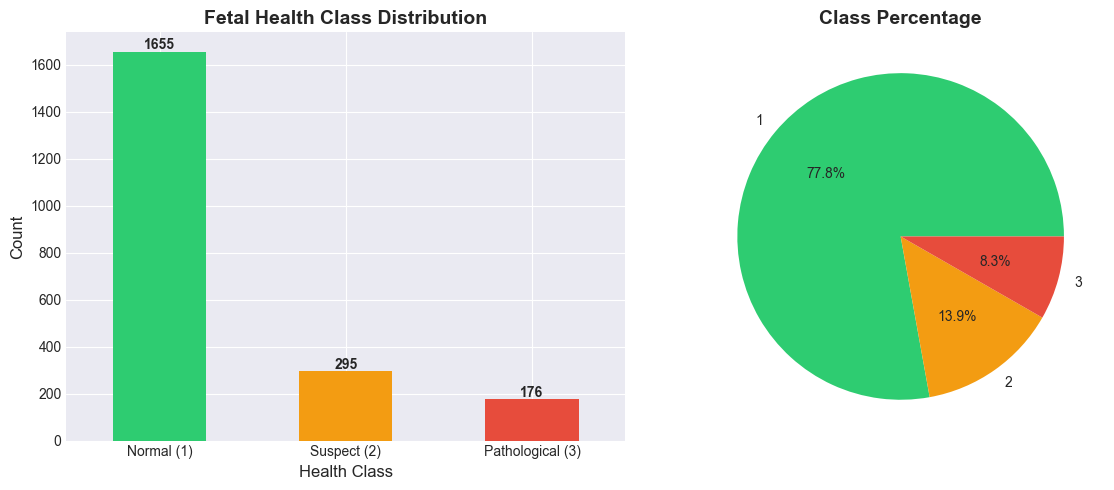

⚠️ DATASET IS IMBALANCED!
Normal cases are 9.4x more common than Pathological cases


In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set style
plt.style.use('seaborn-v0_8-darkgrid')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar plot
colors = ['#2ecc71', '#f39c12', '#e74c3c']
y.value_counts().sort_index().plot(kind='bar', color=colors, ax=axes[0])
axes[0].set_title('Fetal Health Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Health Class', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(['Normal (1)', 'Suspect (2)', 'Pathological (3)'], rotation=0)

# Add count labels on bars
for i, v in enumerate(y.value_counts().sort_index().values):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Pie chart
y.value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', colors=colors, ax=axes[1])
axes[1].set_title('Class Percentage', fontsize=14, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print("⚠️ DATASET IS IMBALANCED!")
print(f"Normal cases are {1655/176:.1f}x more common than Pathological cases")

In [6]:
# Prepare X and y
X = ctg.data.features
y = ctg.data.targets['NSP']

print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nFeature columns ({len(X.columns)}):")
print(X.columns.tolist())

# Check for missing values
print(f"\nMissing values in features: {X.isnull().sum().sum()}")
print(f"Missing values in target: {y.isnull().sum()}")

# Basic statistics
print("\nFeature Statistics (first 5 features):")
print(X.iloc[:, :5].describe().round(2))

Features shape: (2126, 21)
Target shape: (2126,)

Feature columns (21):
['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

Missing values in features: 0
Missing values in target: 0

Feature Statistics (first 5 features):
            LB       AC       FM       UC       DL
count  2126.00  2126.00  2126.00  2126.00  2126.00
mean    133.30     0.00     0.01     0.00     0.00
std       9.84     0.00     0.05     0.00     0.00
min     106.00     0.00     0.00     0.00     0.00
25%     126.00     0.00     0.00     0.00     0.00
50%     133.00     0.00     0.00     0.00     0.00
75%     140.00     0.01     0.00     0.01     0.00
max     160.00     0.02     0.48     0.02     0.02


Top 10 Features Correlated with Fetal Health:
----------------------------------------
DP              : 0.485
ASTV            : 0.471
ALTV            : 0.426
AC              : -0.364
Mode            : -0.250
Mean            : -0.227
MLTV            : -0.227
Variance        : 0.207
Median          : -0.205
UC              : -0.205


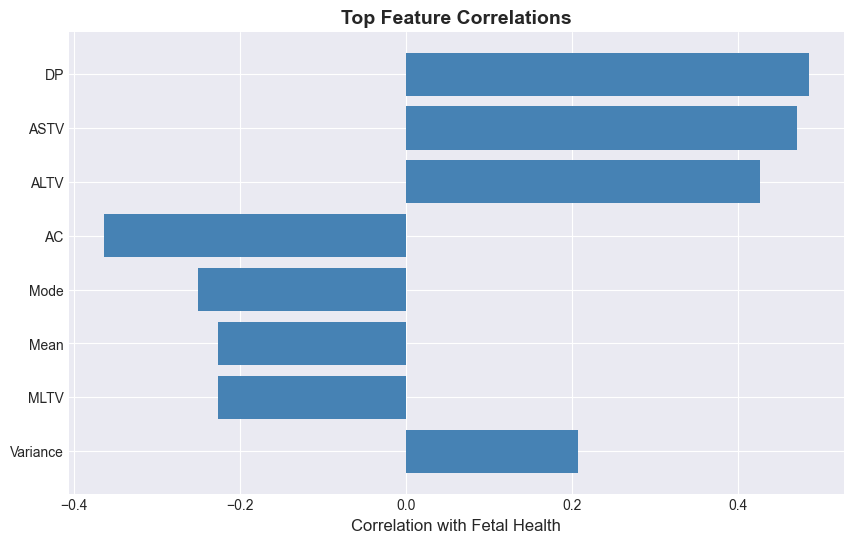

In [7]:
# Check correlation between features and target
correlations = []
for col in X.columns:
    corr = X[col].corr(y)
    correlations.append((col, corr))

# Sort by absolute correlation
correlations.sort(key=lambda x: abs(x[1]), reverse=True)

print("Top 10 Features Correlated with Fetal Health:")
print("-" * 40)
for feature, corr in correlations[:10]:
    print(f"{feature:15} : {corr:.3f}")

# Plot top correlations
top_features = [f[0] for f in correlations[:8]]
top_corrs = [f[1] for f in correlations[:8]]

plt.figure(figsize=(10, 6))
plt.barh(top_features, top_corrs, color='steelblue')
plt.xlabel('Correlation with Fetal Health', fontsize=12)
plt.title('Top Feature Correlations', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.show()

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(y_train.value_counts().sort_index())

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("\n✅ Data prepared for modeling!")

Training set: 1700 samples
Test set: 426 samples

Training class distribution:
NSP
1    1323
2     236
3     141
Name: count, dtype: int64

✅ Data prepared for modeling!


Key Insights from Correlations:
Strongest predictors (positive correlation = worse health):

DP (0.485) - Decelerations (Progressive)

ASTV (0.471) - Abnormal Short Term Variability

ALTV (0.426) - Abnormal Long Term Variability

Protective factors (negative correlation = better health):

AC (-0.364) - Accelerations

Mode, Mean, MLTV (decelerations are bad, accelerations are good!)

Class weights being used:
Class 1: 0.062
Class 2: 0.350
Class 3: 0.587

RANDOM FOREST WITH CLASS WEIGHTS
              precision    recall  f1-score   support

      Normal       0.94      0.98      0.96       332
     Suspect       0.85      0.66      0.74        59
Pathological       0.91      0.89      0.90        35

    accuracy                           0.93       426
   macro avg       0.90      0.84      0.87       426
weighted avg       0.92      0.93      0.92       426



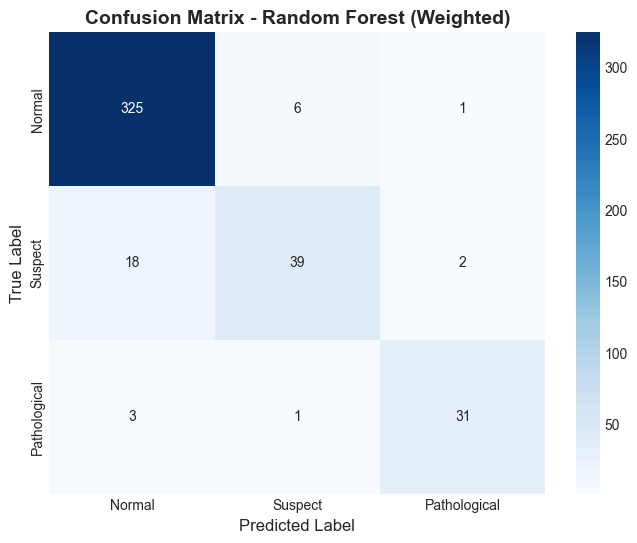

In [9]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns

# Calculate class weights (inverse of frequency)
class_weights = {
    1: 1/1655,  # Normal
    2: 1/295,   # Suspect  
    3: 1/176    # Pathological
}
# Normalize weights
total = sum(class_weights.values())
class_weights = {k: v/total for k, v in class_weights.items()}

print("Class weights being used:")
for class_label, weight in class_weights.items():
    print(f"Class {class_label}: {weight:.3f}")

# Train Random Forest with class weights
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight={1: class_weights[1], 2: class_weights[2], 3: class_weights[3]},
    random_state=42,
    n_jobs=-1
)

rf_weighted.fit(X_train_scaled, y_train)
y_pred_weighted = rf_weighted.predict(X_test_scaled)

print("\n" + "="*50)
print("RANDOM FOREST WITH CLASS WEIGHTS")
print("="*50)
print(classification_report(y_test, y_pred_weighted, target_names=['Normal', 'Suspect', 'Pathological']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_weighted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Suspect', 'Pathological'],
            yticklabels=['Normal', 'Suspect', 'Pathological'])
plt.title('Confusion Matrix - Random Forest (Weighted)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

CELL 9- Alternative (Using Class Weights Only):


Class weights being used:
Class 1: 0.428
Class 2: 2.401
Class 3: 4.019

RANDOM FOREST WITH CLASS WEIGHTS
              precision    recall  f1-score   support

      Normal       0.94      0.99      0.96       332
     Suspect       0.90      0.64      0.75        59
Pathological       0.91      0.91      0.91        35

    accuracy                           0.93       426
   macro avg       0.92      0.85      0.88       426
weighted avg       0.93      0.93      0.93       426



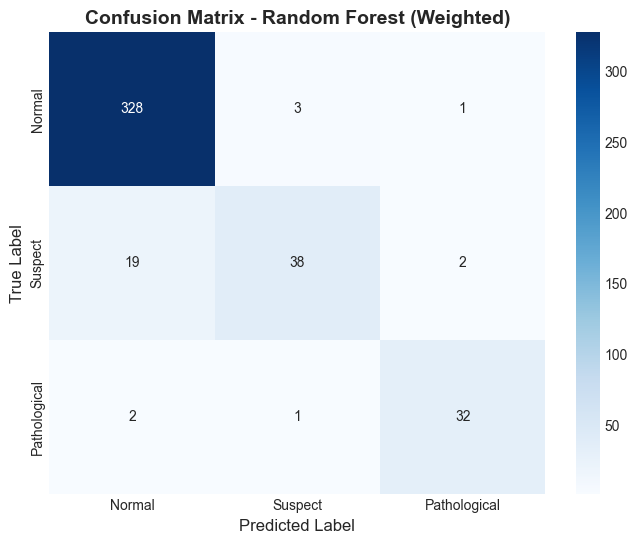


F1-Score (Macro): 0.877
F1-Score (Weighted): 0.930


In [10]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate class weights (inverse of frequency)
class_counts = y_train.value_counts()
class_weights = {
    1: len(y_train) / (3 * class_counts[1]),  # Normal
    2: len(y_train) / (3 * class_counts[2]),  # Suspect
    3: len(y_train) / (3 * class_counts[3])   # Pathological
}

print("Class weights being used:")
for class_label, weight in class_weights.items():
    print(f"Class {class_label}: {weight:.3f}")

# Train Random Forest with class weights
rf_weighted = RandomForestClassifier(
    n_estimators=100,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

rf_weighted.fit(X_train_scaled, y_train)
y_pred_weighted = rf_weighted.predict(X_test_scaled)

print("\n" + "="*50)
print("RANDOM FOREST WITH CLASS WEIGHTS")
print("="*50)
print(classification_report(y_test, y_pred_weighted, target_names=['Normal', 'Suspect', 'Pathological']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_weighted)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Suspect', 'Pathological'],
            yticklabels=['Normal', 'Suspect', 'Pathological'])
plt.title('Confusion Matrix - Random Forest (Weighted)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

# Calculate F1 scores
f1_macro = f1_score(y_test, y_pred_weighted, average='macro')
f1_weighted = f1_score(y_test, y_pred_weighted, average='weighted')
print(f"\nF1-Score (Macro): {f1_macro:.3f}")
print(f"F1-Score (Weighted): {f1_weighted:.3f}")

CELL 10

TOP 15 MOST IMPORTANT FEATURES FOR FETAL HEALTH
 8. ASTV            : 0.133640
10. ALTV            : 0.131491
18. Mean            : 0.093239
 9. MSTV            : 0.078488
19. Median          : 0.076770
 7. DP              : 0.061399
 2. AC              : 0.060656
11. MLTV            : 0.055654
17. Mode            : 0.053375
20. Variance        : 0.045518
 1. LB              : 0.042373
12. Width           : 0.031584
13. Min             : 0.030705
14. Max             : 0.026235
 4. UC              : 0.023804


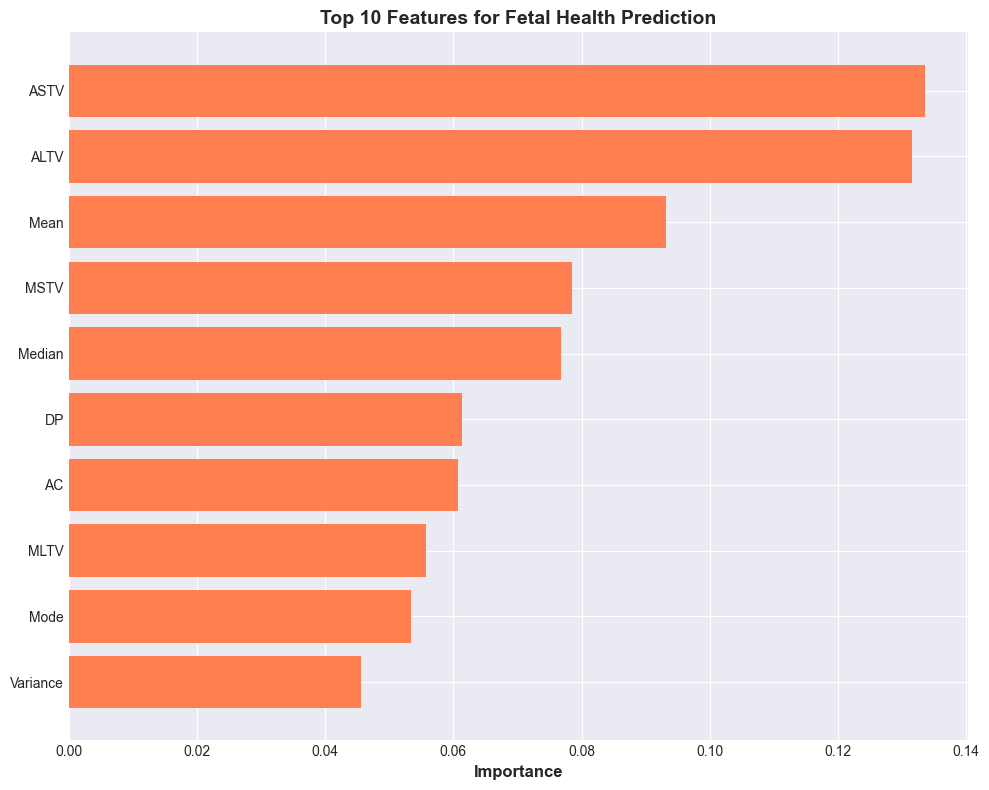


✅ Feature importance saved!


In [11]:
# Get feature importance
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': rf_weighted.feature_importances_
}).sort_values('importance', ascending=False)

print("="*50)
print("TOP 15 MOST IMPORTANT FEATURES FOR FETAL HEALTH")
print("="*50)
for i, row in feature_importance.head(15).iterrows():
    print(f"{i+1:2}. {row['feature']:15} : {row['importance']:4f}")

# Visualize top 10
plt.figure(figsize=(10, 8))
plt.barh(feature_importance.head(10)['feature'], 
         feature_importance.head(10)['importance'], 
         color='coral')
plt.xlabel('Importance', fontsize=12, fontweight='bold')
plt.title('Top 10 Features for Fetal Health Prediction', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Save feature importance for later
feature_importance.to_csv('feature_importance.csv', index=False)
print("\n✅ Feature importance saved!")

CELL 11

Searching for best parameters... (this may take 2-3 minutes)
Fitting 3 folds for each of 108 candidates, totalling 324 fits

✅ Best parameters: {'max_depth': 30, 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best cross-validation F1-macro: 0.904

TUNED RANDOM FOREST RESULTS
              precision    recall  f1-score   support

      Normal       0.95      0.97      0.96       332
     Suspect       0.84      0.69      0.76        59
Pathological       0.89      0.91      0.90        35

    accuracy                           0.93       426
   macro avg       0.89      0.86      0.87       426
weighted avg       0.93      0.93      0.93       426



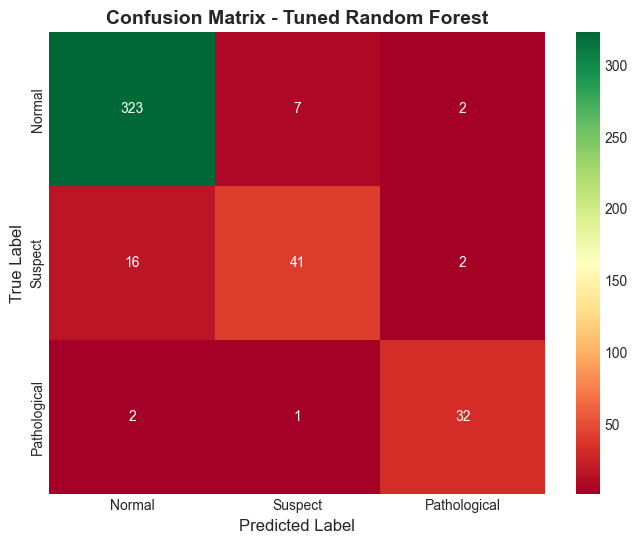

In [12]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

print("Searching for best parameters... (this may take 2-3 minutes)")

# Grid search with class weights
rf_tuned = RandomForestClassifier(
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

grid_search = GridSearchCV(
    rf_tuned, 
    param_grid, 
    cv=3, 
    scoring='f1_macro',
    verbose=1,
    n_jobs=-1
)

grid_search.fit(X_train_scaled, y_train)

print(f"\n✅ Best parameters: {grid_search.best_params_}")
print(f"Best cross-validation F1-macro: {grid_search.best_score_:.3f}")

# Evaluate best model
best_rf = grid_search.best_estimator_
y_pred_tuned = best_rf.predict(X_test_scaled)

print("\n" + "="*50)
print("TUNED RANDOM FOREST RESULTS")
print("="*50)
print(classification_report(y_test, y_pred_tuned, target_names=['Normal', 'Suspect', 'Pathological']))

# Confusion matrix for tuned model
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_tuned, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['Normal', 'Suspect', 'Pathological'],
            yticklabels=['Normal', 'Suspect', 'Pathological'])
plt.title('Confusion Matrix - Tuned Random Forest', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

CELL 12

In [13]:
import joblib

# Save the best model and scaler
model_filename = 'models/fetal_health_model.pkl'
joblib.dump(best_rf, model_filename)
print(f"✅ Model saved to {model_filename}")

# Save the scaler
scaler_filename = 'models/scaler.pkl'
joblib.dump(scaler, scaler_filename)
print(f"✅ Scaler saved to {scaler_filename}")

print("\n📁 Files saved successfully!")

# Quick test prediction
sample = X_test_scaled[0:1]
prediction = best_rf.predict(sample)[0]
prediction_proba = best_rf.predict_proba(sample)[0]

class_names = {1: 'Normal', 2: 'Suspect', 3: 'Pathological'}
print(f"\nTest prediction example:")
print(f"Predicted class: {class_names[prediction]}")
print(f"Probabilities: Normal: {prediction_proba[0]:.2%}, Suspect: {prediction_proba[1]:.2%}, Pathological: {prediction_proba[2]:.2%}")

✅ Model saved to models/fetal_health_model.pkl
✅ Scaler saved to models/scaler.pkl

📁 Files saved successfully!

Test prediction example:
Predicted class: Normal
Probabilities: Normal: 99.55%, Suspect: 0.00%, Pathological: 0.45%


CELL 13-  Save the Tuned Model:

In [17]:
import joblib

# Save the BEST model (from tuning)
joblib.dump(best_rf, 'models/fetal_health_best_model.pkl')
joblib.dump(scaler, 'models/scaler.pkl')

print("✅ Best model saved successfully!")
print(f"Model type: {type(best_rf).__name__}")
print(f"Features used: {len(X.columns)} features")

✅ Best model saved successfully!
Model type: RandomForestClassifier
Features used: 21 features


Create a Prediction Function:
Cell 14 - Test Individual Predictions:

In [15]:
def predict_fetal_health(features_dict):
    """
    Predict fetal health from feature dictionary
    """
    # Convert dict to dataframe with correct column order
    input_df = pd.DataFrame([features_dict])[X.columns]
    
    # Scale the features
    input_scaled = scaler.transform(input_df)
    
    # Predict
    prediction = best_rf.predict(input_scaled)[0]
    probabilities = best_rf.predict_proba(input_scaled)[0]
    
    # Map to labels
    health_status = {1: 'Normal', 2: 'Suspect', 3: 'Pathological'}
    
    return {
        'prediction': health_status[prediction],
        'confidence': max(probabilities) * 100,
        'probabilities': {
            'Normal': probabilities[0] * 100,
            'Suspect': probabilities[1] * 100,
            'Pathological': probabilities[2] * 100
        }
    }

# Example prediction using a sample
sample_features = X_test.iloc[0].to_dict()
result = predict_fetal_health(sample_features)

print("Sample Prediction:")
print(f"Predicted Health: {result['prediction']}")
print(f"Confidence: {result['confidence']:.1f}%")
print("\nProbabilities:")
for status, prob in result['probabilities'].items():
    print(f"  {status}: {prob:.1f}%")

Sample Prediction:
Predicted Health: Normal
Confidence: 99.5%

Probabilities:
  Normal: 99.5%
  Suspect: 0.0%
  Pathological: 0.5%


Next Steps - Build Streamlit App:

In [18]:
# Get the exact feature order your model expects
print("Your model expects these 21 features in this EXACT order:")
print(list(X.columns))
print(f"\nTotal features: {len(X.columns)}")

Your model expects these 21 features in this EXACT order:
['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

Total features: 21


In [3]:
# See column names
print("Feature columns:")
print(ctg.data.features.columns.tolist())
print(f"\nNumber of features: {len(ctg.data.features.columns)}")

# Check the target columns
print("\nTarget columns:")
print(ctg.data.targets.columns.tolist())
print(ctg.data.targets.head())

Feature columns:
['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV', 'MLTV', 'Width', 'Min', 'Max', 'Nmax', 'Nzeros', 'Mode', 'Mean', 'Median', 'Variance', 'Tendency']

Number of features: 21

Target columns:
['CLASS', 'NSP']
   CLASS  NSP
0      9    2
1      6    1
2      6    1
3      6    1
4      2    1


In [4]:
# Usually the fetal health classification is in column 'NSP' (Fetal State Classification)
# 1 = Normal, 2 = Suspect, 3 = Pathological

# Assuming the target is the last column
y = ctg.data.targets.iloc[:, -1]  # or ctg.data.targets['NSP']
print("Target distribution:")
print(y.value_counts().sort_index())
print("\nClass meanings:")
print("1 = Normal")
print("2 = Suspect") 
print("3 = Pathological")

Target distribution:
NSP
1    1655
2     295
3     176
Name: count, dtype: int64

Class meanings:
1 = Normal
2 = Suspect
3 = Pathological


In [5]:
# Basic statistics of features
print("Feature statistics:")
print(ctg.data.features.describe())

# Check for missing values
print(f"\nMissing values: {ctg.data.features.isnull().sum().sum()}")

Feature statistics:
                LB           AC           FM           UC           DL  \
count  2126.000000  2126.000000  2126.000000  2126.000000  2126.000000   
mean    133.303857     0.003178     0.009481     0.004366     0.001889   
std       9.840844     0.003866     0.046666     0.002946     0.002960   
min     106.000000     0.000000     0.000000     0.000000     0.000000   
25%     126.000000     0.000000     0.000000     0.002000     0.000000   
50%     133.000000     0.002000     0.000000     0.004000     0.000000   
75%     140.000000     0.006000     0.003000     0.007000     0.003000   
max     160.000000     0.019000     0.481000     0.015000     0.015000   

                DS           DP         ASTV         MSTV        ALTV  ...  \
count  2126.000000  2126.000000  2126.000000  2126.000000  2126.00000  ...   
mean      0.000003     0.000159    46.990122     1.332785     9.84666  ...   
std       0.000057     0.000590    17.192814     0.883241    18.39688  ...   
m

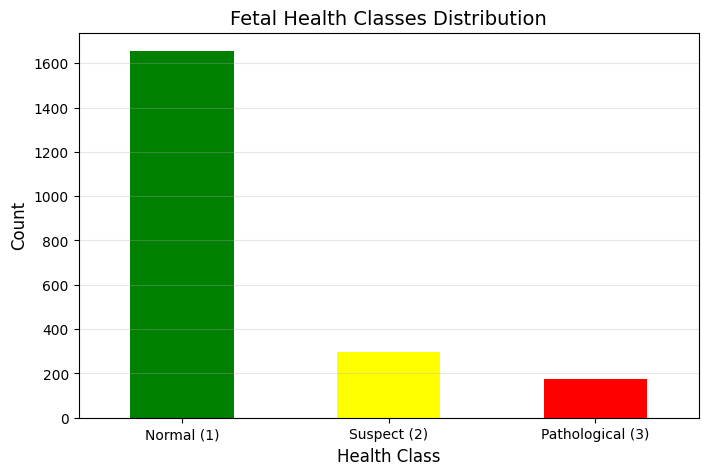

Class percentages:
NSP
1    77.845720
2    13.875823
3     8.278457
Name: proportion, dtype: float64


In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot target distribution
plt.figure(figsize=(8,5))
y.value_counts().sort_index().plot(kind='bar', color=['green', 'yellow', 'red'])
plt.title('Fetal Health Classes Distribution', fontsize=14)
plt.xlabel('Health Class', fontsize=12)
plt.ylabel('Count', fontsize=12)
plt.xticks([0,1,2], ['Normal (1)', 'Suspect (2)', 'Pathological (3)'], rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.show()

print(f"Class percentages:")
print(y.value_counts(normalize=True).sort_index() * 100)